# IMPORT LIBRARIES

In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import randint as sp_randint

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

#from scikitplot.metrics import plot_roc

from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours


from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

from imblearn.combine import SMOTEENN
from imblearn.combine import SMOTETomek



In [5]:
#!pip install category_encoders

# LOAD CSV

In [4]:
pd.set_option('display.max_colwidth', None)  # Show full content in columns
pd.set_option('display.max_rows', None)

In [32]:
df = pd.read_csv("dataset/train_post_outlier.csv")

In [33]:
pd.set_option("display.max_colwidth", None)  # Show full content in columns
pd.set_option("display.max_rows", None)

# FAST CHECK AND PROCESS

In [34]:
df = df.drop(columns=["Unnamed: 0", "rating_category"])

In [35]:
print(round((df['isAdult'].value_counts()*100)/df.shape[0]))

isAdult
0    98.0
1     2.0
Name: count, dtype: float64


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115507 entries, 0 to 115506
Data columns (total 59 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   runtimeMinutes           115507 non-null  float64
 1   criticReviewsTotal       115507 non-null  float64
 2   canHaveEpisodes          115507 non-null  bool   
 3   isAdult                  115507 non-null  int64  
 4   numRegions               115507 non-null  float64
 5   castNumber               115507 non-null  float64
 6   companiesNumber          115507 non-null  float64
 7   averageRating            115507 non-null  float64
 8   writerCredits            115507 non-null  float64
 9   directorsCredits         115507 non-null  float64
 10  quotesTotal              115507 non-null  float64
 11  genre_Action             115507 non-null  int64  
 12  genre_Adventure          115507 non-null  int64  
 13  genre_Animation          115507 non-null  int64  
 14  genr

# IMBALANCED LEARNING

In [38]:
target = 'isAdult'

attributes = [col for col in df.columns if col != target]

X = df[attributes].values
y = np.array(df[target]) 
X.shape, y.shape

((115507, 58), (115507,))

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((92405, 58), (23102, 58), (92405,), (23102,))

## BASELINE MODELS

### DECISION TREE

In [40]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))


Migliori parametri trovati: {'min_samples_split': 40, 'min_samples_leaf': 20, 'max_depth': 50, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.94      0.81      0.87       438

    accuracy                           1.00     23102
   macro avg       0.97      0.90      0.93     23102
weighted avg       1.00      1.00      1.00     23102



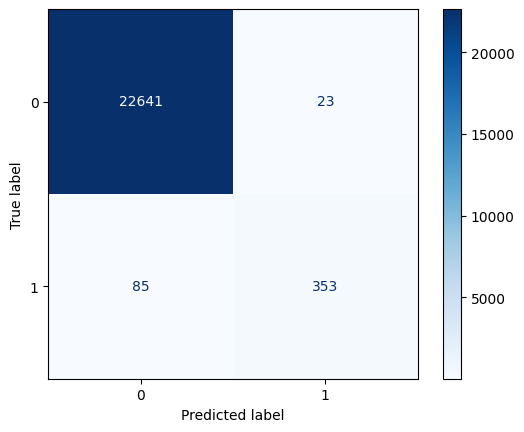

In [41]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


### KNN

In [42]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_train, y_train) 

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

Migliori parametri trovati: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.82      0.77      0.79       438

    accuracy                           0.99     23102
   macro avg       0.91      0.88      0.89     23102
weighted avg       0.99      0.99      0.99     23102



## UNDERSAMPLING

### RANDOM

In [43]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 1750, np.int64(1): 1750})


In [44]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_randomunder = grid_search

Migliori parametri trovati: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 50, 'criterion': 'gini'}
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     22664
           1       0.33      0.94      0.49       438

    accuracy                           0.96     23102
   macro avg       0.67      0.95      0.74     23102
weighted avg       0.99      0.96      0.97     23102



In [45]:
knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_randomunder = random_search

Migliori parametri trovati: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     22664
           1       0.14      0.97      0.24       438

    accuracy                           0.88     23102
   macro avg       0.57      0.92      0.59     23102
weighted avg       0.98      0.88      0.92     23102



### TOMEK

In [46]:
tl = TomekLinks(sampling_strategy= 'majority')
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 90489, np.int64(1): 1750})


In [47]:
X_res.shape

(92239, 58)

In [48]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_tomek = grid_search

Migliori parametri trovati: {'min_samples_split': 30, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.93      0.82      0.87       438

    accuracy                           1.00     23102
   macro avg       0.96      0.91      0.93     23102
weighted avg       1.00      1.00      1.00     23102



In [49]:
knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_tomek = random_search

Migliori parametri trovati: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.81      0.78      0.79       438

    accuracy                           0.99     23102
   macro avg       0.90      0.89      0.90     23102
weighted avg       0.99      0.99      0.99     23102



### EDITED NEAREST NEIGHBOURS

In [50]:
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 89124, np.int64(1): 1750})


In [51]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_enn = grid_search



Migliori parametri trovati: {'min_samples_split': 40, 'min_samples_leaf': 5, 'max_depth': 20, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.88      0.85      0.86       438

    accuracy                           0.99     23102
   macro avg       0.94      0.92      0.93     23102
weighted avg       0.99      0.99      0.99     23102



"\nEdited nearest neighbor\nMigliori parametri trovati: {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 50, 'criterion': 'gini'}\n              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00     25440\n           1       0.86      0.90      0.88       493\n\n    accuracy                           1.00     25933\n   macro avg       0.93      0.95      0.94     25933\nweighted avg       1.00      1.00      1.00     25933\n"

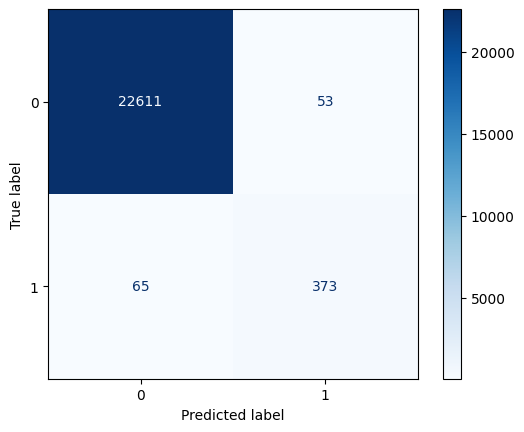

In [52]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


In [53]:
knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_enn = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     22664
           1       0.61      0.80      0.69       438

    accuracy                           0.99     23102
   macro avg       0.80      0.90      0.84     23102
weighted avg       0.99      0.99      0.99     23102



## OVERSAMPLING

### Random 

In [54]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 90655, np.int64(1): 90655})


In [55]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_over = grid_search

Migliori parametri trovati: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'gini'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.85      0.81      0.83       438

    accuracy                           0.99     23102
   macro avg       0.92      0.90      0.91     23102
weighted avg       0.99      0.99      0.99     23102



In [56]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_over = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22664
           1       0.70      0.71      0.71       438

    accuracy                           0.99     23102
   macro avg       0.85      0.85      0.85     23102
weighted avg       0.99      0.99      0.99     23102



### Smote

In [57]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 90655, np.int64(1): 90655})


In [58]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_smote = grid_search

Migliori parametri trovati: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.86      0.82      0.84       438

    accuracy                           0.99     23102
   macro avg       0.93      0.91      0.92     23102
weighted avg       0.99      0.99      0.99     23102



In [59]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_smote = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     22664
           1       0.56      0.79      0.66       438

    accuracy                           0.98     23102
   macro avg       0.78      0.89      0.82     23102
weighted avg       0.99      0.98      0.99     23102



### Adasyn

In [60]:
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 90655, np.int64(1): 90552})


In [61]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_ada = grid_search

Migliori parametri trovati: {'min_samples_split': 40, 'min_samples_leaf': 20, 'max_depth': 30, 'criterion': 'gini'}
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     22664
           1       0.76      0.85      0.80       438

    accuracy                           0.99     23102
   macro avg       0.88      0.92      0.90     23102
weighted avg       0.99      0.99      0.99     23102



In [62]:

knn = KNeighborsClassifier()

# Definizione dei parametri da ottimizzare
param_dist = {
    'n_neighbors': sp_randint(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Configurazione della Random Search
random_search = RandomizedSearchCV(estimator=knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Addestramento del modello
random_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {random_search.best_params_}")

# Predizioni sul set di test
y_pred = random_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

knn_ada = random_search

Migliori parametri trovati: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     22664
           1       0.55      0.79      0.65       438

    accuracy                           0.98     23102
   macro avg       0.78      0.89      0.82     23102
weighted avg       0.99      0.98      0.99     23102



BEST ONE IS DECISION  TREE WITH ENN

Edited Nearest Neighbors (ENN) removes majority examples whose class disagrees with the majority of their k nearest neighbors (usually k=3).

This clears out noisy/ambiguous non‑adults near adult clusters, so your tree doesn’t over‑generalize and label everything in those neighborhoods as “adult.”

You keep nearly the full majority class, so you don’t pay the heavy precision price of random undersampling.

## MIX

### SMOTEENN

In [63]:
# 1. Inspect resampled distribution (optional)
smoteenn = SMOTEENN(random_state=42)
X_res, y_res = smoteenn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(1): 90644, np.int64(0): 87840})


In [64]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_smotenn = grid_search


Migliori parametri trovati: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     22664
           1       0.76      0.87      0.81       438

    accuracy                           0.99     23102
   macro avg       0.88      0.93      0.90     23102
weighted avg       0.99      0.99      0.99     23102



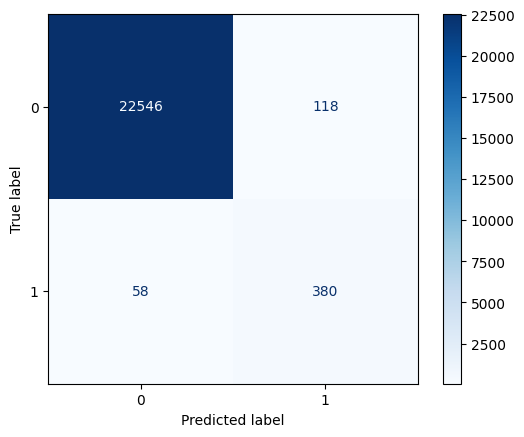

In [65]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


### SMOTETomek

In [66]:
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({np.int64(0): 90654, np.int64(1): 90654})


In [67]:
# DT con grid

dtree = DecisionTreeClassifier(random_state=42)

# Definizione dei parametri da ottimizzare
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 5, 10, 20, 30, 40]
}

# Configurazione della Grid Search
grid_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_grid, n_iter=10,  cv=5, n_jobs=-1)

# Addestramento del modello
grid_search.fit(X_res, y_res)

# Migliori parametri trovati
print(f"Migliori parametri trovati: {grid_search.best_params_}")

# Predizioni sul set di test
y_pred = grid_search.predict(X_test)

# Report di classificazione
print(classification_report(y_test, y_pred))

dt_smotenn = grid_search


Migliori parametri trovati: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22664
           1       0.86      0.82      0.84       438

    accuracy                           0.99     23102
   macro avg       0.93      0.91      0.92     23102
weighted avg       0.99      0.99      0.99     23102



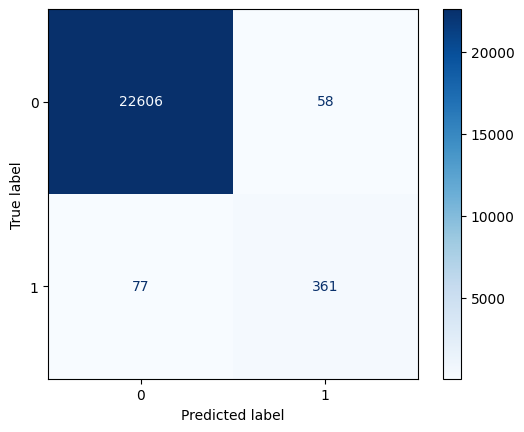

In [68]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')
